# Part2 RegGS: All-Non-Train Test Rendering and Evaluation

这个 notebook 用于**单独执行 test 渲染+评测**，支持：

1. 使用 `all_non_train` 协议（测试集 = 所有非训练帧）
2. 按与最近训练帧距离筛选要渲染的 test 帧
3. 保存渲染图、可选保存 GT 图、可选保存 test pose
4. 输出独立的 metrics json，避免覆盖已有结果

注意：这是一个独立 notebook，不会修改 RegGS 库代码。

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import torch
import torchvision
from torchvision.utils import save_image

# -------- Workspace Paths (standalone notebook) --------
CV_ROOT = Path('/home/bzhang512/CV_Project')
PART2_ROOT = CV_ROOT / 'part2'
REGGS_ROOT = CV_ROOT / 'third_party' / 'RegGS'
OUTPUT_ROOT = CV_ROOT / 'output' / 'part2'
CONFIG_ROOT = PART2_ROOT / 'configs'

assert REGGS_ROOT.exists(), f'RegGS root not found: {REGGS_ROOT}'
assert OUTPUT_ROOT.exists(), f'Output root not found: {OUTPUT_ROOT}'
assert CONFIG_ROOT.exists(), f'Config root not found: {CONFIG_ROOT}'

print('CV_ROOT =', CV_ROOT)
print('REGGS_ROOT =', REGGS_ROOT)
print('OUTPUT_ROOT =', OUTPUT_ROOT)
print('CONFIG_ROOT =', CONFIG_ROOT)

CV_ROOT = /home/bzhang512/CV_Project
REGGS_ROOT = /home/bzhang512/CV_Project/third_party/RegGS
OUTPUT_ROOT = /home/bzhang512/CV_Project/output/part2
CONFIG_ROOT = /home/bzhang512/CV_Project/part2/configs


## 1) 选择运行目录和配置

- `DATASET_KEY`: 对应 `output/part2/<dataset_key>`
- `RUN_NAME`: 具体 run 目录名
- `CONFIG_PATH`: 默认使用 `part2/configs/<RUN_NAME>.yaml`，不存在时回退到 `RUN_OUTPUT/config.yaml`

In [11]:
# -------- Run Selection --------
# 可选: 're10k_1', 'dl3dv_2', '405841'
DATASET_KEY = '405841'
DATASET_KEY = 're10k_1'
DATASET_KEY = 'dl3dv_2'


# 你可以直接改成目标 run
RUN_NAME = 'reggs_405841_scene_C_dl3dv-ckpt_sr30_nv12_sm2_stable_v1'
RUN_NAME = 'reggs_re10k1_re10k-ckpt_sr50_nv9_sm2_comparison_check'
RUN_NAME = '/home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10'

# 也可留空并自动选择该数据集目录下按修改时间最新的 run
AUTO_PICK_LATEST_IF_EMPTY = False

dataset_output_dir = OUTPUT_ROOT / DATASET_KEY
assert dataset_output_dir.exists(), f'Dataset output dir missing: {dataset_output_dir}'

if AUTO_PICK_LATEST_IF_EMPTY or (RUN_NAME is None) or (str(RUN_NAME).strip() == ''):
    candidates = [p for p in dataset_output_dir.iterdir() if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f'No run dirs found under: {dataset_output_dir}')
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)
    RUN_NAME = candidates[0].name

RUN_OUTPUT = dataset_output_dir / RUN_NAME
assert RUN_OUTPUT.exists(), f'Run output not found: {RUN_OUTPUT}'

CONFIG_PATH = CONFIG_ROOT / f'{RUN_NAME}.yaml'
if not CONFIG_PATH.exists():
    fallback_cfg = RUN_OUTPUT / 'config.yaml'
    if fallback_cfg.exists():
        CONFIG_PATH = fallback_cfg
    else:
        raise FileNotFoundError(
            f'Config not found in configs and run dir: {CONFIG_ROOT / (RUN_NAME + ".yaml")}, {fallback_cfg}'
        )

print('DATASET_KEY =', DATASET_KEY)
print('RUN_NAME =', RUN_NAME)
print('RUN_OUTPUT =', RUN_OUTPUT)
print('CONFIG_PATH =', CONFIG_PATH)

DATASET_KEY = dl3dv_2
RUN_NAME = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10
RUN_OUTPUT = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10
CONFIG_PATH = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10/config.yaml


## 2) Test 协议与筛帧参数

你主要改这个单元里的参数：

- `TEST_PROTOCOL`: 通常设为 `all_non_train`
- `OUTPUT_TAG`: 控制输出目录和 json 文件名后缀
- `SELECTION_MODE`: `all` / `gap_step` / `manual`
- `MIN_GAP_TO_TRAIN` 等：用于 `gap_step` 筛选
- `DO_POSE_OPT`: 开启更准但更慢；关闭更快
- `SAVE_TEST_POSES`: 是否额外保存 test pose 到 ckpt

In [12]:
# -------- Test Protocol and Frame Selection --------
TEST_PROTOCOL = 'all_non_train'   # 'sampled_test' or 'all_non_train'
OUTPUT_TAG = 'all_non_train_subset_v1'

# 选择模式:
# - 'all': 使用协议返回的全部 test 帧
# - 'gap_step': 按与最近 train 帧距离筛选
# - 'manual': 仅使用 MANUAL_FRAME_IDS
SELECTION_MODE = 'all'

# gap_step 参数
MIN_GAP_TO_TRAIN = 20
MAX_GAP_TO_TRAIN = None   # 例如 80；None 表示不设上限
TAKE_EVERY_N = 3          # 在候选中每 N 帧保留 1 帧
MAX_KEEP = None           # 例如 50；None 表示不截断

# manual 参数
MANUAL_FRAME_IDS = []     # 例如 [15, 45, 75]

# 额外包含/排除
FORCE_INCLUDE = []
FORCE_EXCLUDE = []

# 渲染和保存控制
DO_POSE_OPT = True
SAVE_GT_IMAGES = False
SAVE_TEST_POSES = True

print('TEST_PROTOCOL =', TEST_PROTOCOL)
print('OUTPUT_TAG =', OUTPUT_TAG)
print('SELECTION_MODE =', SELECTION_MODE)
print('DO_POSE_OPT =', DO_POSE_OPT)
print('SAVE_GT_IMAGES =', SAVE_GT_IMAGES)
print('SAVE_TEST_POSES =', SAVE_TEST_POSES)

TEST_PROTOCOL = all_non_train
OUTPUT_TAG = all_non_train_subset_v1
SELECTION_MODE = all
DO_POSE_OPT = True
SAVE_GT_IMAGES = False
SAVE_TEST_POSES = True


In [13]:
# -------- Import RegGS Modules and Build Evaluator --------
if str(REGGS_ROOT) not in sys.path:
    sys.path.insert(0, str(REGGS_ROOT))

from src.evaluation.evaluator import Evaluator
from src.utils.utils import get_render_settings, render_gaussian_model
from src.utils.metrics_utils import compute_psnr, compute_ssim, compute_lpips

if TEST_PROTOCOL not in {'sampled_test', 'all_non_train'}:
    raise ValueError('TEST_PROTOCOL must be sampled_test/all_non_train')

evaluator = Evaluator(
    Path(RUN_OUTPUT),
    Path(CONFIG_PATH),
    test_protocol=TEST_PROTOCOL,
    test_output_tag=OUTPUT_TAG,
)

if evaluator.refined_gaussians is None:
    raise RuntimeError('No gaussian model found in run output.')

print('Evaluator ready.')
print('train frames =', len(evaluator.train_frame_ids))
print('test frames (protocol) =', len(evaluator.test_frame_ids))

[Evaluator] Using gaussian file: /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10/gaussians/global_refined_gs.ply
Training Frames: [  0  33  67 101 136 169 203 237 271 305]
Eval Frames (all_non_train): [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 102 103 104 105 106 107 108 109 110 111
 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 131 132 133 134 135 137 138 139 140 141 142 143 144 145 146 147 148
 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 19

In [14]:
# -------- Build Selected Test Frame List --------
train_ids = np.array(evaluator.train_frame_ids, dtype=int)
test_ids = np.array(evaluator.test_frame_ids, dtype=int)

if test_ids.size == 0:
    raise RuntimeError('No test frames found under current protocol.')

# 每个 test 帧到最近 train 帧的距离
dist_to_nearest_train = np.min(np.abs(test_ids[:, None] - train_ids[None, :]), axis=1)
dist_map = {int(fid): int(d) for fid, d in zip(test_ids.tolist(), dist_to_nearest_train.tolist())}

if SELECTION_MODE == 'all':
    selected_ids = test_ids.copy()
elif SELECTION_MODE == 'manual':
    selected_ids = np.array(sorted(set(int(x) for x in MANUAL_FRAME_IDS)), dtype=int)
elif SELECTION_MODE == 'gap_step':
    mask = dist_to_nearest_train >= int(MIN_GAP_TO_TRAIN)
    if MAX_GAP_TO_TRAIN is not None:
        mask = mask & (dist_to_nearest_train <= int(MAX_GAP_TO_TRAIN))
    selected_ids = test_ids[mask]
    if TAKE_EVERY_N is not None and int(TAKE_EVERY_N) > 1:
        selected_ids = selected_ids[::int(TAKE_EVERY_N)]
    if MAX_KEEP is not None:
        selected_ids = selected_ids[:int(MAX_KEEP)]
else:
    raise ValueError('SELECTION_MODE must be one of all/manual/gap_step')

if FORCE_INCLUDE:
    selected_ids = np.unique(np.concatenate([selected_ids, np.array([int(x) for x in FORCE_INCLUDE])]))
if FORCE_EXCLUDE:
    excluded = set(int(x) for x in FORCE_EXCLUDE)
    selected_ids = np.array([x for x in selected_ids if int(x) not in excluded], dtype=int)

selected_ids = np.array(sorted(int(x) for x in selected_ids.tolist()), dtype=int)
if selected_ids.size == 0:
    raise RuntimeError('No selected test frames. Please relax selection parameters.')

selected_dist = [dist_map.get(int(fid), int(np.min(np.abs(train_ids - int(fid))))) for fid in selected_ids]

print('train count =', len(train_ids))
print('test count (protocol) =', len(test_ids))
print('selected count =', len(selected_ids))
print('selected head =', selected_ids[:20].tolist())
print('selected gap head =', selected_dist[:20])

train count = 10
test count (protocol) = 296
selected count = 296
selected head = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
selected gap head = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 16, 15, 14, 13]


In [ ]:
# -------- Render Selected Test Frames and Evaluate --------
run_dir = Path(RUN_OUTPUT)
render_dir = run_dir / evaluator._test_render_dir()
gt_dir = run_dir / evaluator._test_gt_dir()
metrics_path = run_dir / evaluator._test_metrics_filename()
pose_path = run_dir / f'estimated_test_c2w_{evaluator.test_output_label}.ckpt'

render_dir.mkdir(parents=True, exist_ok=True)
if SAVE_GT_IMAGES:
    gt_dir.mkdir(parents=True, exist_ok=True)

print('render_dir =', render_dir)
if SAVE_GT_IMAGES:
    print('gt_dir =', gt_dir)
print('metrics_path =', metrics_path)
if SAVE_TEST_POSES:
    print('pose_path =', pose_path)

device = evaluator.device
dataset = evaluator.dataset
model = evaluator.refined_gaussians
transform = torchvision.transforms.ToTensor()

gt_c2ws = torch.tensor(dataset.poses).to(device)
est_train_c2ws = evaluator.estimated_c2ws
est_test_c2ws = evaluator.compute_estimated_test_c2ws(
    gt_c2ws, est_train_c2ws, train_ids, selected_ids
)

metrics_rows = []
saved_poses = []

for idx, frame_id in enumerate(selected_ids):
    frame_id = int(frame_id)
    est_c2w = est_test_c2ws[idx]

    if DO_POSE_OPT:
        est_c2w = evaluator.optimize_estimated_c2w(model, est_c2w, frame_id)

    with torch.no_grad():
        w2c = torch.inverse(est_c2w)
        render_settings = get_render_settings(
            dataset.width, dataset.height, dataset.intrinsics, w2c.detach().cpu().numpy()
        )
        render_dict = render_gaussian_model(model, render_settings)

        gt_color = transform(dataset[frame_id][1]).to(device)
        pred_color = render_dict['color'].clamp(0, 1)

        psnr = compute_psnr(gt_color, pred_color).item()
        ssim = compute_ssim(gt_color, pred_color).item()
        lpips = compute_lpips(gt_color, pred_color).item()

    save_image(pred_color, render_dir / f'color_{frame_id:04d}.png')
    if SAVE_GT_IMAGES:
        save_image(gt_color, gt_dir / f'gt_{frame_id:04d}.png')

    if SAVE_TEST_POSES:
        saved_poses.append(est_c2w.detach().cpu())

    gap = int(np.min(np.abs(train_ids - frame_id)))
    metrics_rows.append({
        'frame_id': f'{frame_id:04d}',
        'frame_id_int': frame_id,
        'dist_to_nearest_train': gap,
        'psnr': psnr,
        'ssim': ssim,
        'lpips': lpips,
    })

    print(f'[{idx + 1:04d}/{len(selected_ids):04d}] frame={frame_id:04d} gap={gap:03d} '
          f'PSNR={psnr:.2f} SSIM={ssim:.3f} LPIPS={lpips:.3f}')

avg_psnr = float(np.mean([r['psnr'] for r in metrics_rows]))
avg_ssim = float(np.mean([r['ssim'] for r in metrics_rows]))
avg_lpips = float(np.mean([r['lpips'] for r in metrics_rows]))

payload = {
    'test_protocol': TEST_PROTOCOL,
    'output_tag': evaluator.test_output_label,
    'selection_mode': SELECTION_MODE,
    'selection_params': {
        'min_gap_to_train': MIN_GAP_TO_TRAIN,
        'max_gap_to_train': MAX_GAP_TO_TRAIN,
        'take_every_n': TAKE_EVERY_N,
        'max_keep': MAX_KEEP,
        'manual_frame_ids': MANUAL_FRAME_IDS,
        'force_include': FORCE_INCLUDE,
        'force_exclude': FORCE_EXCLUDE,
        'do_pose_opt': DO_POSE_OPT,
        'save_gt_images': SAVE_GT_IMAGES,
        'save_test_poses': SAVE_TEST_POSES,
    },
    'n_train_frames': int(len(train_ids)),
    'n_test_frames_protocol': int(len(test_ids)),
    'n_test_frames_selected': int(len(selected_ids)),
    'avg_psnr': avg_psnr,
    'avg_ssim': avg_ssim,
    'avg_lpips': avg_lpips,
    'metrics': metrics_rows,
}

with metrics_path.open('w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

if SAVE_TEST_POSES:
    torch.save(
        {
            'frame_ids': [int(x) for x in selected_ids.tolist()],
            'estimated_test_c2w': torch.stack(saved_poses, dim=0) if len(saved_poses) > 0 else torch.empty(0, 4, 4),
            'test_protocol': TEST_PROTOCOL,
            'output_tag': evaluator.test_output_label,
        },
        pose_path
    )

print('Done.')
print('avg_psnr =', avg_psnr)
print('avg_ssim =', avg_ssim)
print('avg_lpips =', avg_lpips)

/home/bzhang512/miniconda3/envs/reggs/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


render_dir = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10/test_all_non_train_subset_v1
metrics_path = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10/eval_test_all_non_train_subset_v1.json
pose_path = /home/bzhang512/my_storage_500G/CV_Project/output/part2/dl3dv_2/reggs_dl3dv2_dl3dv-ckpt_sr30_nv10/estimated_test_c2w_all_non_train_subset_v1.ckpt
Optimizing pose for frame 0001...


  0%|          | 0/400 [00:00<?, ?it/s, loss=4.35e+3]

100%|██████████| 400/400 [00:08<00:00, 47.75it/s, loss=3.68e+3]


[0001/0296] frame=0001 gap=001 PSNR=29.39 SSIM=0.926 LPIPS=0.042
Optimizing pose for frame 0002...


...

100%|██████████| 400/400 [00:28<00:00, 14.19it/s, loss=3.64e+4]


[0295/0296] frame=0303 gap=002 PSNR=11.69 SSIM=0.279 LPIPS=0.661
Optimizing pose for frame 0304...


100%|██████████| 400/400 [00:28<00:00, 14.23it/s, loss=3.61e+4]


[0296/0296] frame=0304 gap=001 PSNR=11.77 SSIM=0.273 LPIPS=0.656
Done.
avg_psnr = 15.792936102764026
avg_ssim = 0.4430072599568883
avg_lpips = 0.48163133650716095


: 

In [7]:
# -------- Optional: Compute Test ATE From Existing Outputs (no run-all needed) --------
from pathlib import Path
import json
import sys
import numpy as np
import torch
import yaml

# 0) Resolve run output path (standalone-friendly)
DEFAULT_RUN_OUTPUT = Path(
    '/home/bzhang512/my_storage_500G/CV_Project/output/part2/405841'
    '/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1'
 )
run_output = Path(globals().get('RUN_OUTPUT', DEFAULT_RUN_OUTPUT))
if run_output.is_file():
    run_output = run_output.parent
assert run_output.exists() and run_output.is_dir(), f'Invalid run_output: {run_output}'

# 1) Pick eval_test*.json (prefer current OUTPUT_TAG if present)
eval_candidates = sorted(run_output.glob('eval_test*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
assert eval_candidates, f'No eval_test*.json found under: {run_output}'

target_eval = None
output_tag_hint = str(globals().get('OUTPUT_TAG', '')).strip()
if output_tag_hint:
    preferred = run_output / f'eval_test_{output_tag_hint}.json'
    if preferred.exists():
        target_eval = preferred
if target_eval is None:
    target_eval = eval_candidates[0]

with target_eval.open('r', encoding='utf-8') as f:
    test_payload = json.load(f)

# 2) Parse test frame ids and output label
test_metrics = test_payload.get('metrics', [])
assert len(test_metrics) > 0, f'No metrics in {target_eval}'
if 'frame_id_int' in test_metrics[0]:
    test_frame_ids = np.array([int(x['frame_id_int']) for x in test_metrics], dtype=int)
else:
    test_frame_ids = np.array([int(str(x['frame_id'])) for x in test_metrics], dtype=int)

test_output_label = test_payload.get('output_tag')
if not test_output_label:
    file_name = target_eval.name
    if file_name == 'eval_test.json':
        test_output_label = 'sampled'
    elif file_name.startswith('eval_test_') and file_name.endswith('.json'):
        test_output_label = file_name[len('eval_test_'):-len('.json')]
    else:
        test_output_label = 'unknown'

# 3) Load estimated test poses from ckpt
pose_candidates = sorted(run_output.glob('estimated_test_c2w*.ckpt'), key=lambda p: p.stat().st_mtime, reverse=True)
assert pose_candidates, f'No estimated_test_c2w*.ckpt found under: {run_output}'

target_pose = None
label_pose = run_output / f'estimated_test_c2w_{test_output_label}.ckpt'
if label_pose.exists():
    target_pose = label_pose
if target_pose is None and output_tag_hint:
    hint_pose = run_output / f'estimated_test_c2w_{output_tag_hint}.ckpt'
    if hint_pose.exists():
        target_pose = hint_pose
if target_pose is None:
    target_pose = pose_candidates[0]

pose_data = torch.load(target_pose, map_location='cpu')
if isinstance(pose_data, dict) and 'estimated_test_c2w' in pose_data:
    est_test_c2w = pose_data['estimated_test_c2w']
else:
    est_test_c2w = pose_data

if not torch.is_tensor(est_test_c2w):
    est_test_c2w = torch.tensor(est_test_c2w)
est_test_c2w = est_test_c2w.detach().cpu().float()
if est_test_c2w.ndim != 3 or est_test_c2w.shape[1:] != (4, 4):
    raise ValueError(f'Invalid est_test_c2w shape: {tuple(est_test_c2w.shape)}')

# 4) Resolve config path and load GT poses via RegGS dataset loader
default_cfg = run_output / 'config.yaml'
cfg_path = Path(globals().get('CONFIG_PATH', default_cfg))
if not cfg_path.exists():
    cfg_path = default_cfg
assert cfg_path.exists(), f'Config not found: {cfg_path}'

reggs_root = Path(globals().get('REGGS_ROOT', '/home/bzhang512/CV_Project/third_party/RegGS'))
assert reggs_root.exists(), f'RegGS root not found: {reggs_root}'
if str(reggs_root) not in sys.path:
    sys.path.insert(0, str(reggs_root))

from src.entities.datasets import get_dataset

with cfg_path.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

dataset = get_dataset(cfg['dataset_name'])({**cfg['data'], **cfg['cam']})
gt_poses = np.array(dataset.poses, dtype=np.float32)
assert gt_poses.ndim == 3 and gt_poses.shape[1:] == (4, 4), f'Invalid gt_poses shape: {gt_poses.shape}'

# 5) Align sequence lengths safely
n_eval = len(test_frame_ids)
n_pose = est_test_c2w.shape[0]
n_use = min(n_eval, n_pose)
if n_use <= 1:
    raise ValueError(f'Not enough pose pairs for ATE: n_eval={n_eval}, n_pose={n_pose}')
if n_use < n_eval or n_use < n_pose:
    print(f'[WARN] length mismatch; truncating to n_use={n_use} (n_eval={n_eval}, n_pose={n_pose})')

test_frame_ids = test_frame_ids[:n_use]
est_test_c2w = est_test_c2w[:n_use]

gt_test_c2w = gt_poses[test_frame_ids]
gt_t = gt_test_c2w[:, :3, 3]
est_t = est_test_c2w[:, :3, 3].numpy()

# 6) Utility functions: Umeyama alignment + ATE stats
def ate_stats(diff):
    # diff: [N, 3]
    err = np.linalg.norm(diff, axis=1)
    return {
        'compared_pose_pairs': int(err.shape[0]),
        'rmse': float(np.sqrt(np.mean(err ** 2))),
        'mean': float(np.mean(err)),
        'median': float(np.median(err)),
        'std': float(np.std(err)),
        'min': float(np.min(err)),
        'max': float(np.max(err)),
    }

def umeyama_align(src, dst):
    # src, dst: [N, 3]
    src_mean = src.mean(axis=0, keepdims=True)
    dst_mean = dst.mean(axis=0, keepdims=True)
    src_c = src - src_mean
    dst_c = dst - dst_mean

    cov = (dst_c.T @ src_c) / src.shape[0]
    U, S, Vt = np.linalg.svd(cov)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = U @ Vt

    var_src = np.mean(np.sum(src_c ** 2, axis=1))
    if var_src <= 1e-12:
        raise ValueError('Degenerate source trajectory for alignment')
    scale = np.sum(S) / var_src

    t = (dst_mean.reshape(3) - scale * (R @ src_mean.reshape(3)))
    aligned = (scale * (R @ src.T)).T + t
    return aligned, R, t, scale

# 7) Compute raw/aligned test ATE
raw = ate_stats(est_t - gt_t)
aligned_t, R, t, scale = umeyama_align(est_t, gt_t)
aligned = ate_stats(aligned_t - gt_t)

# 8) Read train ATE (if exists) for side-by-side reference
train_ate_path = run_output / 'ate_aligned.json'
train_ate = None
if train_ate_path.exists():
    with train_ate_path.open('r', encoding='utf-8') as f:
        train_ate = json.load(f)

# 9) Save outputs
out_test_ate = run_output / f'ate_test_{test_output_label}.json'
out_compare = run_output / f'ate_compare_{test_output_label}.json'

test_payload_out = {
    'source_eval_test_json': str(target_eval),
    'source_estimated_test_pose_ckpt': str(target_pose),
    'source_config': str(cfg_path),
    'test_output_label': str(test_output_label),
    'test_protocol': test_payload.get('test_protocol', 'unknown'),
    'n_pose_used': int(n_use),
    'raw_test_ate': raw,
    'aligned_test_ate': aligned,
    'umeyama': {
        'scale': float(scale),
        'R': R.tolist(),
        't': t.tolist(),
    },
}

compare_payload = {
    'train_ate_aligned': train_ate,
    'test_ate_raw': raw,
    'test_ate_aligned': aligned,
    'source_eval_test_json': str(target_eval),
    'source_estimated_test_pose_ckpt': str(target_pose),
}

with out_test_ate.open('w', encoding='utf-8') as f:
    json.dump(test_payload_out, f, indent=2, ensure_ascii=False)
with out_compare.open('w', encoding='utf-8') as f:
    json.dump(compare_payload, f, indent=2, ensure_ascii=False)

# 10) Print concise summary
print('run_output =', run_output)
print('target_eval =', target_eval.name)
print('target_pose =', target_pose.name)
print('n_pose_used =', n_use)
print('train_ate_path =', train_ate_path if train_ate_path.exists() else 'MISSING')
print('test_raw_rmse =', raw['rmse'])
print('test_aligned_rmse =', aligned['rmse'])
if train_ate is not None and 'rmse' in train_ate:
    print('train_aligned_rmse =', train_ate['rmse'])
print('wrote =', out_test_ate)
print('wrote =', out_compare)

run_output = /home/bzhang512/my_storage_500G/CV_Project/output/part2/405841/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1
target_eval = eval_test_all_non_train_subset_v1.json
target_pose = estimated_test_c2w_all_non_train_subset_v1.ckpt
n_pose_used = 179
train_ate_path = /home/bzhang512/my_storage_500G/CV_Project/output/part2/405841/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1/ate_aligned.json
test_raw_rmse = 38.775047302246094
test_aligned_rmse = 19.29405975341797
train_aligned_rmse = 18.983081879828354
wrote = /home/bzhang512/my_storage_500G/CV_Project/output/part2/405841/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1/ate_test_all_non_train_subset_v1.json
wrote = /home/bzhang512/my_storage_500G/CV_Project/output/part2/405841/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1/ate_compare_all_non_train_subset_v1.json


/tmp/ipykernel_2822529/1808121063.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pose_data = torch.load(target_pose, map_location='cpu')


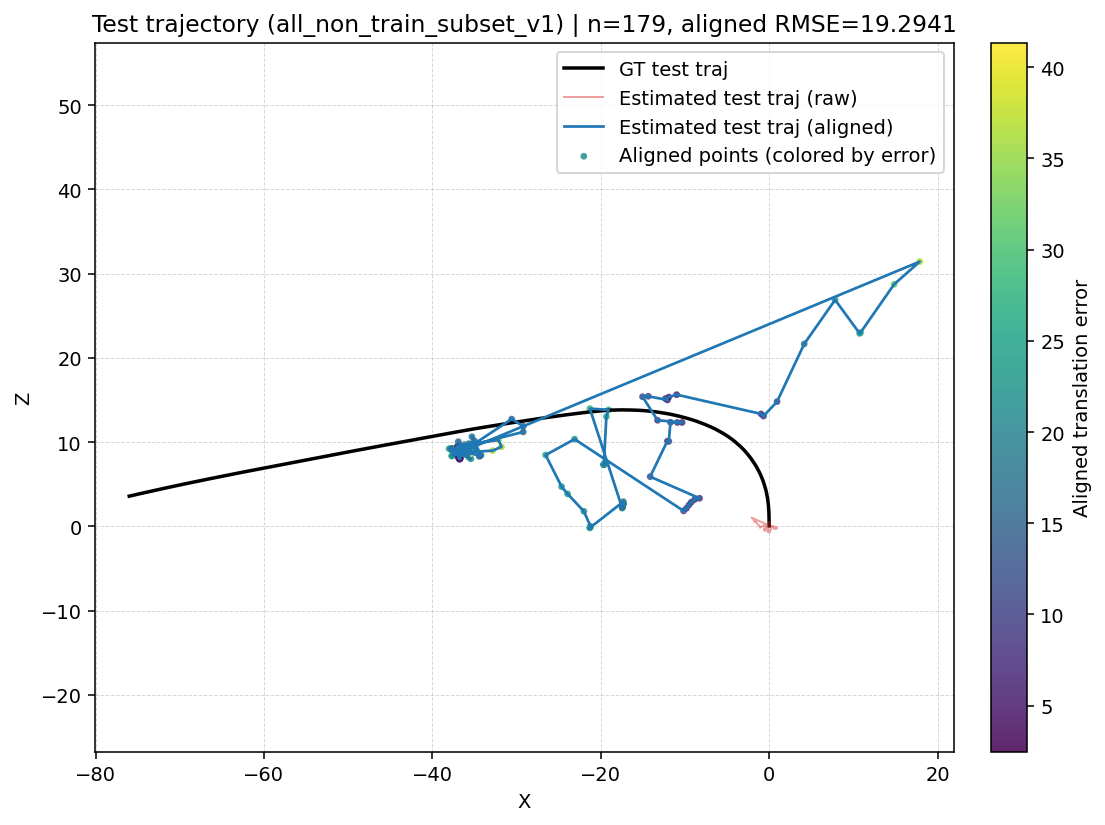

wrote = /home/bzhang512/my_storage_500G/CV_Project/output/part2/405841/reggs_405841_scene_full_dl3dv-ckpt_sr30_nv20_sm2_stable_v1/eval_test_traj_all_non_train_subset_v1.png


In [8]:
# -------- Optional: Plot Test Trajectory PNG From Current ATE Variables --------
import numpy as np
import matplotlib.pyplot as plt

required_vars = ['run_output', 'test_output_label', 'gt_t', 'aligned_t', 'est_t', 'aligned']
missing = [k for k in required_vars if k not in globals()]
if missing:
    raise RuntimeError(
        'Missing variables from previous ATE cell: ' + ', '.join(missing) +
        '. Please run the ATE cell first.'
    )

# Ensure numpy arrays with shape [N, 3]
gt_np = np.asarray(gt_t, dtype=np.float32)
aligned_np = np.asarray(aligned_t, dtype=np.float32)
est_np = np.asarray(est_t, dtype=np.float32)
if gt_np.ndim != 2 or gt_np.shape[1] != 3:
    raise ValueError(f'Invalid gt_t shape: {gt_np.shape}')
if aligned_np.ndim != 2 or aligned_np.shape[1] != 3:
    raise ValueError(f'Invalid aligned_t shape: {aligned_np.shape}')
if est_np.ndim != 2 or est_np.shape[1] != 3:
    raise ValueError(f'Invalid est_t shape: {est_np.shape}')

n_plot = min(len(gt_np), len(aligned_np), len(est_np))
if n_plot <= 1:
    raise ValueError(f'Not enough points to plot trajectory: n_plot={n_plot}')

gt_np = gt_np[:n_plot]
aligned_np = aligned_np[:n_plot]
est_np = est_np[:n_plot]

# Per-frame XY(or XZ) error after alignment for color visualization
err_aligned = np.linalg.norm(aligned_np - gt_np, axis=1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=140)

# Match common trajectory style on X-Z plane
ax.plot(gt_np[:, 0], gt_np[:, 2], color='black', linewidth=1.8, label='GT test traj')
ax.plot(est_np[:, 0], est_np[:, 2], color='tab:red', alpha=0.45, linewidth=1.0, label='Estimated test traj (raw)')
ax.plot(aligned_np[:, 0], aligned_np[:, 2], color='tab:blue', linewidth=1.4, label='Estimated test traj (aligned)')

sc = ax.scatter(
    aligned_np[:, 0],
    aligned_np[:, 2],
    c=err_aligned,
    cmap='viridis',
    s=12,
    alpha=0.85,
    edgecolors='none',
    label='Aligned points (colored by error)'
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Aligned translation error')

ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_title(
    f'Test trajectory ({test_output_label}) | '
    f'n={n_plot}, aligned RMSE={float(aligned["rmse"]):.4f}'
)
ax.axis('equal')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='best')

out_plot = run_output / f'eval_test_traj_{test_output_label}.png'
fig.tight_layout()
fig.savefig(out_plot, bbox_inches='tight')
plt.show()
plt.close(fig)

print('wrote =', out_plot)

## 3) 使用说明（简版）

1. 先改 `DATASET_KEY` 和 `RUN_NAME`，确认 `RUN_OUTPUT` 与 `CONFIG_PATH`
2. 将 `TEST_PROTOCOL` 设为 `all_non_train`
3. 调整 `SELECTION_MODE` 与筛帧参数
4. 执行最后一个渲染单元
5. 结果在：
   - 渲染图：`RUN_OUTPUT/test_<output_tag>/`
   - GT 图：`RUN_OUTPUT/gt_<output_tag>/`（若开启）
   - 指标：`RUN_OUTPUT/eval_test_<output_tag>.json`
   - pose：`RUN_OUTPUT/estimated_test_c2w_<output_tag>.ckpt`（若开启）